# Punto 3 — Clasificación de lengua de señas (27 clases)

**Dataset:** [27 Class Sign Language Dataset — ardamavi](https://www.kaggle.com/datasets/ardamavi/27-class-sign-language-dataset)

**Objetivo:** Entrenar redes neuronales densas que clasifiquen imágenes de mano en 27 clases de lengua de señas basada en ASL.

**Modelos:**
1. DNN Base — 1 capa oculta grande
2. DNN con regularización — Dropout + BatchNormalization
3. DNN Profunda — 4 capas con unidades decrecientes

**Preprocesamiento:** Las imágenes se aplanan a vectores 1-D para ser compatibles con capas Dense.

## 1. Importaciones

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, classification_report
)
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical

tf.random.set_seed(42)
np.random.seed(42)

sns.set_theme(style='whitegrid')
DATA_DIR = Path('../data/sign_language')

print(f'TensorFlow {tf.__version__}')

TensorFlow 2.21.0


## 2. Descarga del dataset

Requiere tener la [API de Kaggle](https://www.kaggle.com/docs/api) configurada (`~/.kaggle/kaggle.json`).
Si ya descargaste el dataset manualmente, coloca los archivos en `../data/sign_language/`.

In [2]:
DATA_DIR.mkdir(parents=True, exist_ok=True)

npy_files = list(DATA_DIR.glob('*.npy'))

if not npy_files:
    print('Descargando dataset desde Kaggle...')
    os.system(f'kaggle datasets download -d ardamavi/27-class-sign-language-dataset -p {DATA_DIR} --unzip')
    npy_files = list(DATA_DIR.glob('**/*.npy'))

print('Archivos .npy encontrados:')
for f in npy_files:
    print(f'  {f.name}  —  {f.stat().st_size / 1e6:.1f} MB')

Archivos .npy encontrados:
  X.npy  —  4482.9 MB
  Y.npy  —  1.6 MB


## 3. Carga y exploración de datos

In [3]:
from sklearn.preprocessing import LabelEncoder

# Cargar imágenes y etiquetas (igual que keras.datasets.mnist.load_data())
X = np.load(DATA_DIR / 'X.npy')
Y = np.load(DATA_DIR / 'Y.npy').flatten()   # aplanar (N,1) → (N,)

# Convertir etiquetas string → enteros ordenados alfabéticamente
le = LabelEncoder()
y_int = le.fit_transform(Y)
CLASS_NAMES = le.classes_
NUM_CLASSES  = len(CLASS_NAMES)

# Normalizar píxeles y aplanar imagen a vector 1-D para capas Dense
X_flat = (X.astype(np.float32) / 255.0).reshape(len(X), -1)

print(f'Imágenes shape: {X.shape}')
print(f'X_flat shape:   {X_flat.shape}  (features = {X_flat.shape[1]})')
print(f'Clases ({NUM_CLASSES}): {CLASS_NAMES}')

Imágenes shape: (22801, 128, 128, 3)
X_flat shape:   (22801, 49152)  (features = 49152)
Clases (27): ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9' 'NULL' 'a' 'b' 'bye' 'c' 'd' 'e'
 'good' 'good morning' 'hello' 'little bit' 'no' 'pardon' 'please'
 'project' 'whats up' 'yes']


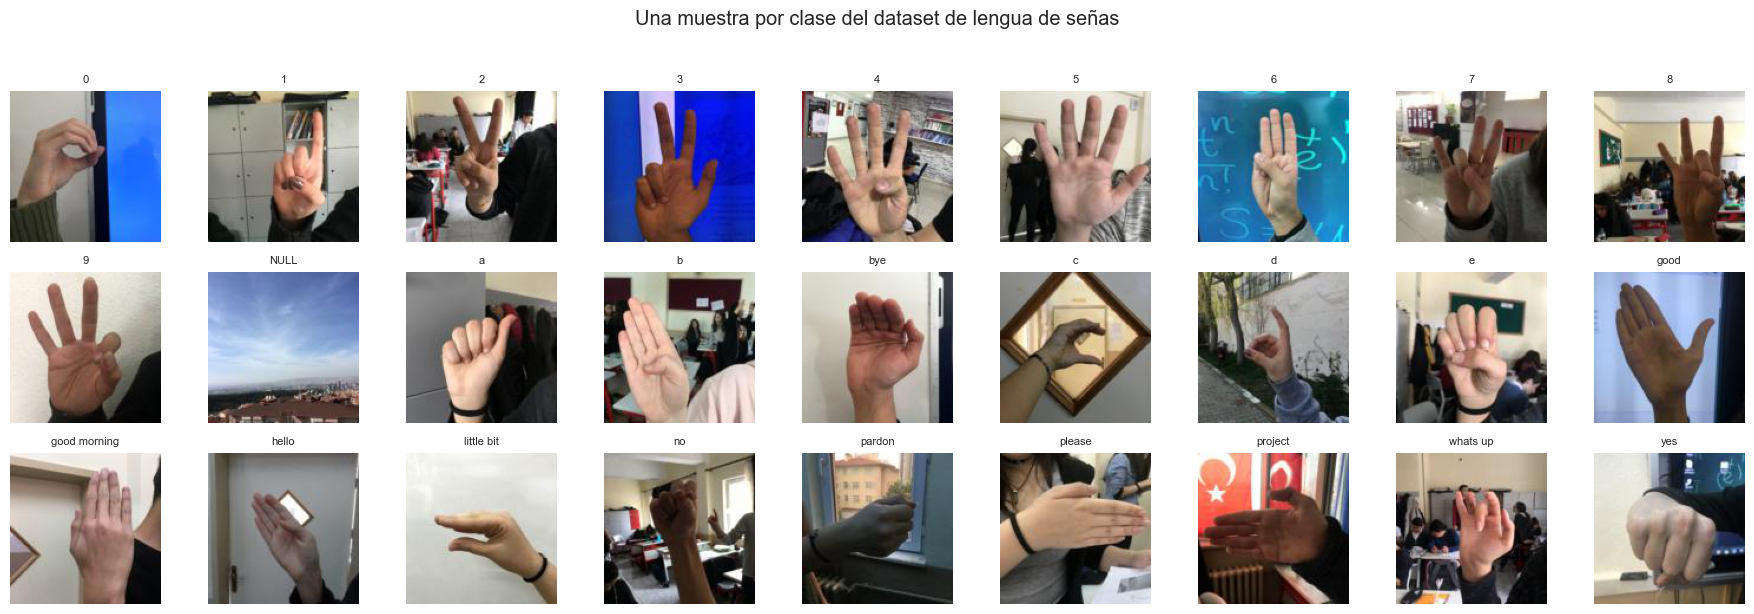

In [4]:
# Una imagen de ejemplo por clase (estilo MNIST)
plt.figure(figsize=(18, 6))
for idx, label in enumerate(np.unique(y_int)):
    plt.subplot(3, 9, idx + 1)
    image = X[y_int == label][0]
    plt.imshow(image, cmap='gray')
    plt.title(CLASS_NAMES[label], fontsize=8)
    plt.axis('off')

plt.suptitle('Una muestra por clase del dataset de lengua de señas', y=1.02)
plt.tight_layout()
plt.show()

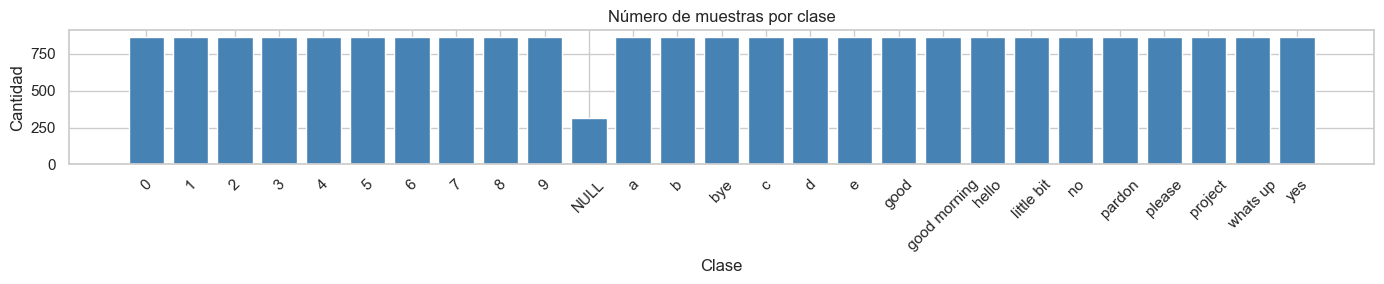

Total de muestras: 22801  |  Promedio por clase: 844


In [5]:
# Distribución de muestras por clase
counts = np.bincount(y_int)
plt.figure(figsize=(14, 3))
plt.bar(CLASS_NAMES, counts, color='steelblue')
plt.title('Número de muestras por clase')
plt.xlabel('Clase')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f'Total de muestras: {len(y_int)}  |  Promedio por clase: {counts.mean():.0f}')

In [6]:
# Resumen del dataset
print(f'Total de muestras:  {len(X)}')
print(f'Tamaño de imagen:   {X.shape[1:]}')
print(f'Features por imagen: {X_flat.shape[1]}')
print(f'Número de clases:   {NUM_CLASSES}')
print()
summary = pd.DataFrame({
    'Clase': CLASS_NAMES,
    'Muestras': np.bincount(y_int)
})
display(summary.T)

Total de muestras:  22801
Tamaño de imagen:   (128, 128, 3)
Features por imagen: 49152
Número de clases:   27



,0,1,2,3,4,5,6,7,8,9,...,17,18,19,20,21,22,23,24,25,26
Clase,0,1,2,3,4,5,6,7,8,9,...,good,good morning,hello,little bit,no,pardon,please,project,whats up,yes
Muestras,866,865,865,865,864,865,865,865,865,865,...,865,865,865,865,865,865,865,865,865,865


## 4. División train/test

In [7]:
from sklearn.utils.class_weight import compute_class_weight
from sklearn.decomposition import PCA

X_train, X_test, y_train_int, y_test_int = train_test_split(
    X_flat, y_int,
    test_size=0.2,
    random_state=42,
    stratify=y_int
)

# ── PCA ──────────────────────────────────────────────────────────────────────
# Con 128×128×3 = 49,152 features y solo ~18k muestras, la primera capa Dense
# tendría 25M parámetros → sobreajuste severo. PCA reduce la dimensionalidad
# eliminando varianza redundante antes de entrar al DNN.
# Se ajusta SOLO sobre train para no filtrar información del test (data leakage).
N_PCA = 256
pca = PCA(n_components=N_PCA, random_state=42)
X_train = pca.fit_transform(X_train)
X_test  = pca.transform(X_test)

explained_var = pca.explained_variance_ratio_.sum()
print(f'PCA: {N_PCA} componentes  |  varianza explicada: {explained_var:.3%}')
print(f'Dimensión original: 49152  →  nueva: {N_PCA}')

y_train = to_categorical(y_train_int, num_classes=NUM_CLASSES)
y_test  = to_categorical(y_test_int,  num_classes=NUM_CLASSES)

# Pesos por clase para compensar desbalance entre clases
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)
class_weight_dict = dict(enumerate(class_weights_arr))

INPUT_DIM = X_train.shape[1]
print(f'\nTrain: {X_train.shape}  Test: {X_test.shape}')
print(f'Input dimension: {INPUT_DIM}')
print(f'Class weights (min={min(class_weights_arr):.3f}, max={max(class_weights_arr):.3f})')

PCA: 256 componentes  |  varianza explicada: 90.380%
Dimensión original: 49152  →  nueva: 256

Train: (18240, 256)  Test: (4561, 256)
Input dimension: 256
Class weights (min=0.975, max=2.691)


## 5. Construcción de modelos

In [9]:
def build_dnn_base(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name='DNN_Base')
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


def build_dnn_regularized(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ], name='DNN_Regularized')
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


def build_dnn_deep(input_dim, num_classes):
    """
    DNN Deep mejorada:
    - LeakyReLU reemplaza ReLU para evitar neuronas muertas.
    - BatchNormalization en todas las capas ocultas.
    - Dropout reducido (0.3 / 0.2) para no sobreregularizar.
    - Eliminado el cuello de botella Dense(64).
    - AdamW añade weight decay implícito como regularización adicional.
    - kernel_regularizer L2 en cada capa Dense para penalizar pesos grandes.
    - Label smoothing (0.1) evita que el modelo sea demasiado confiado,
      lo que mejora la generalización en clases difíciles.
    """
    l2_reg = keras.regularizers.l2(1e-4)

    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(512, kernel_regularizer=l2_reg),
        layers.LeakyReLU(negative_slope=0.1),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(256, kernel_regularizer=l2_reg),
        layers.LeakyReLU(negative_slope=0.1),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(128, kernel_regularizer=l2_reg),
        layers.LeakyReLU(negative_slope=0.1),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(128, kernel_regularizer=l2_reg),
        layers.LeakyReLU(negative_slope=0.1),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(num_classes, activation='softmax')
    ], name='DNN_Deep')

    model.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )
    return model


MODELS = {
    # 'DNN Base':        build_dnn_base,
    'DNN Regularized': build_dnn_regularized
    # 'DNN Deep':        build_dnn_deep
}

EPOCHS     = 150
BATCH_SIZE = 64

## 6. Entrenamiento

In [10]:
trained_models  = {}
histories       = {}
results_sl      = []

for name, builder in MODELS.items():
    print(f'\n{"="*55}')
    print(f'  Entrenando: {name}')
    print(f'{"="*55}')

    tf.random.set_seed(42)
    model = builder(INPUT_DIM, NUM_CLASSES)

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=20, restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6, verbose=0
        ),
    ]

    hist = model.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.15,
        callbacks=callbacks,
        class_weight=class_weight_dict,
        verbose=1
    )

    trained_models[name] = model
    histories[name] = hist

    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred_int  = np.argmax(y_pred_prob, axis=1)

    acc  = accuracy_score(y_test_int, y_pred_int)
    f1   = f1_score(y_test_int, y_pred_int, average='macro')
    f1w  = f1_score(y_test_int, y_pred_int, average='weighted')

    print(f'  Accuracy: {acc:.4f}  |  F1 macro: {f1:.4f}  |  F1 weighted: {f1w:.4f}')
    results_sl.append({
        'Modelo': name,
        'Accuracy': acc,
        'F1 Macro': f1,
        'F1 Weighted': f1w
    })

print('\n✓ Entrenamiento completo.')


  Entrenando: DNN Regularized
Epoch 1/150
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.0920 - loss: 3.5170 - val_accuracy: 0.0424 - val_loss: 3.2631 - learning_rate: 0.0010
Epoch 2/150
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1849 - loss: 2.8837 - val_accuracy: 0.1882 - val_loss: 2.9302 - learning_rate: 0.0010
Epoch 3/150
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 941us/step - accuracy: 0.2490 - loss: 2.5874 - val_accuracy: 0.3136 - val_loss: 2.4512 - learning_rate: 0.0010
Epoch 4/150
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3006 - loss: 2.3873 - val_accuracy: 0.3651 - val_loss: 2.2429 - learning_rate: 0.0010
Epoch 5/150
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 868us/step - accuracy: 0.3351 - loss: 2.2445 - val_accuracy: 0.3783 - val_loss: 2.1651 - learning_rate: 0.0010
Epoch 6/150
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 988us/step - accuracy: 0.3693 - loss: 2.1105 - val_accuracy: 0.3841 - val_loss: 2.1017 - learning_rate: 0.0010
Epoch 7/150
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 8

## 7. Tabla comparativa de resultados

In [11]:
df_sl = pd.DataFrame(results_sl).set_index('Modelo')
print('=== Resultados — Clasificación de Lengua de Señas ===')
display(df_sl.round(4))

=== Resultados — Clasificación de Lengua de Señas ===


,Accuracy,F1 Macro,F1 Weighted
Modelo,,,
DNN Regularized,0.5578,0.5562,0.5584


## 8. Curvas de entrenamiento

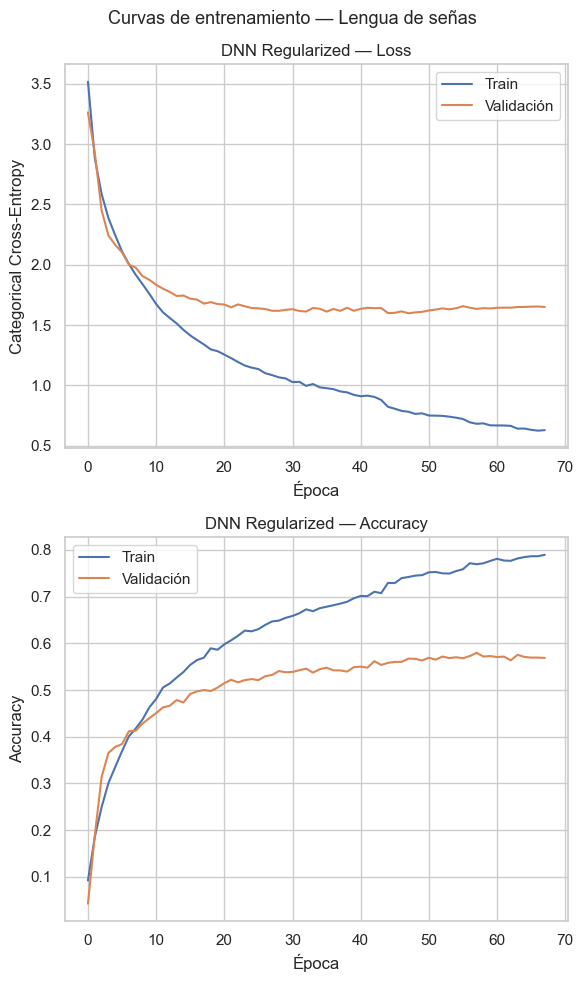

In [12]:
n_models = len(histories)
fig, axes = plt.subplots(2, n_models, figsize=(6 * n_models, 10))
# Garantizar que axes sea siempre 2-D aunque haya un solo modelo
if n_models == 1:
    axes = np.array(axes).reshape(2, 1)

for col, (name, hist) in enumerate(histories.items()):
    axes[0, col].plot(hist.history['loss'],     label='Train')
    axes[0, col].plot(hist.history['val_loss'], label='Validación')
    axes[0, col].set_title(f'{name} — Loss')
    axes[0, col].set_xlabel('Época')
    axes[0, col].set_ylabel('Categorical Cross-Entropy')
    axes[0, col].legend()

    axes[1, col].plot(hist.history['accuracy'],     label='Train')
    axes[1, col].plot(hist.history['val_accuracy'], label='Validación')
    axes[1, col].set_title(f'{name} — Accuracy')
    axes[1, col].set_xlabel('Época')
    axes[1, col].set_ylabel('Accuracy')
    axes[1, col].legend()

plt.suptitle('Curvas de entrenamiento — Lengua de señas', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Matriz de confusión (mejor modelo)

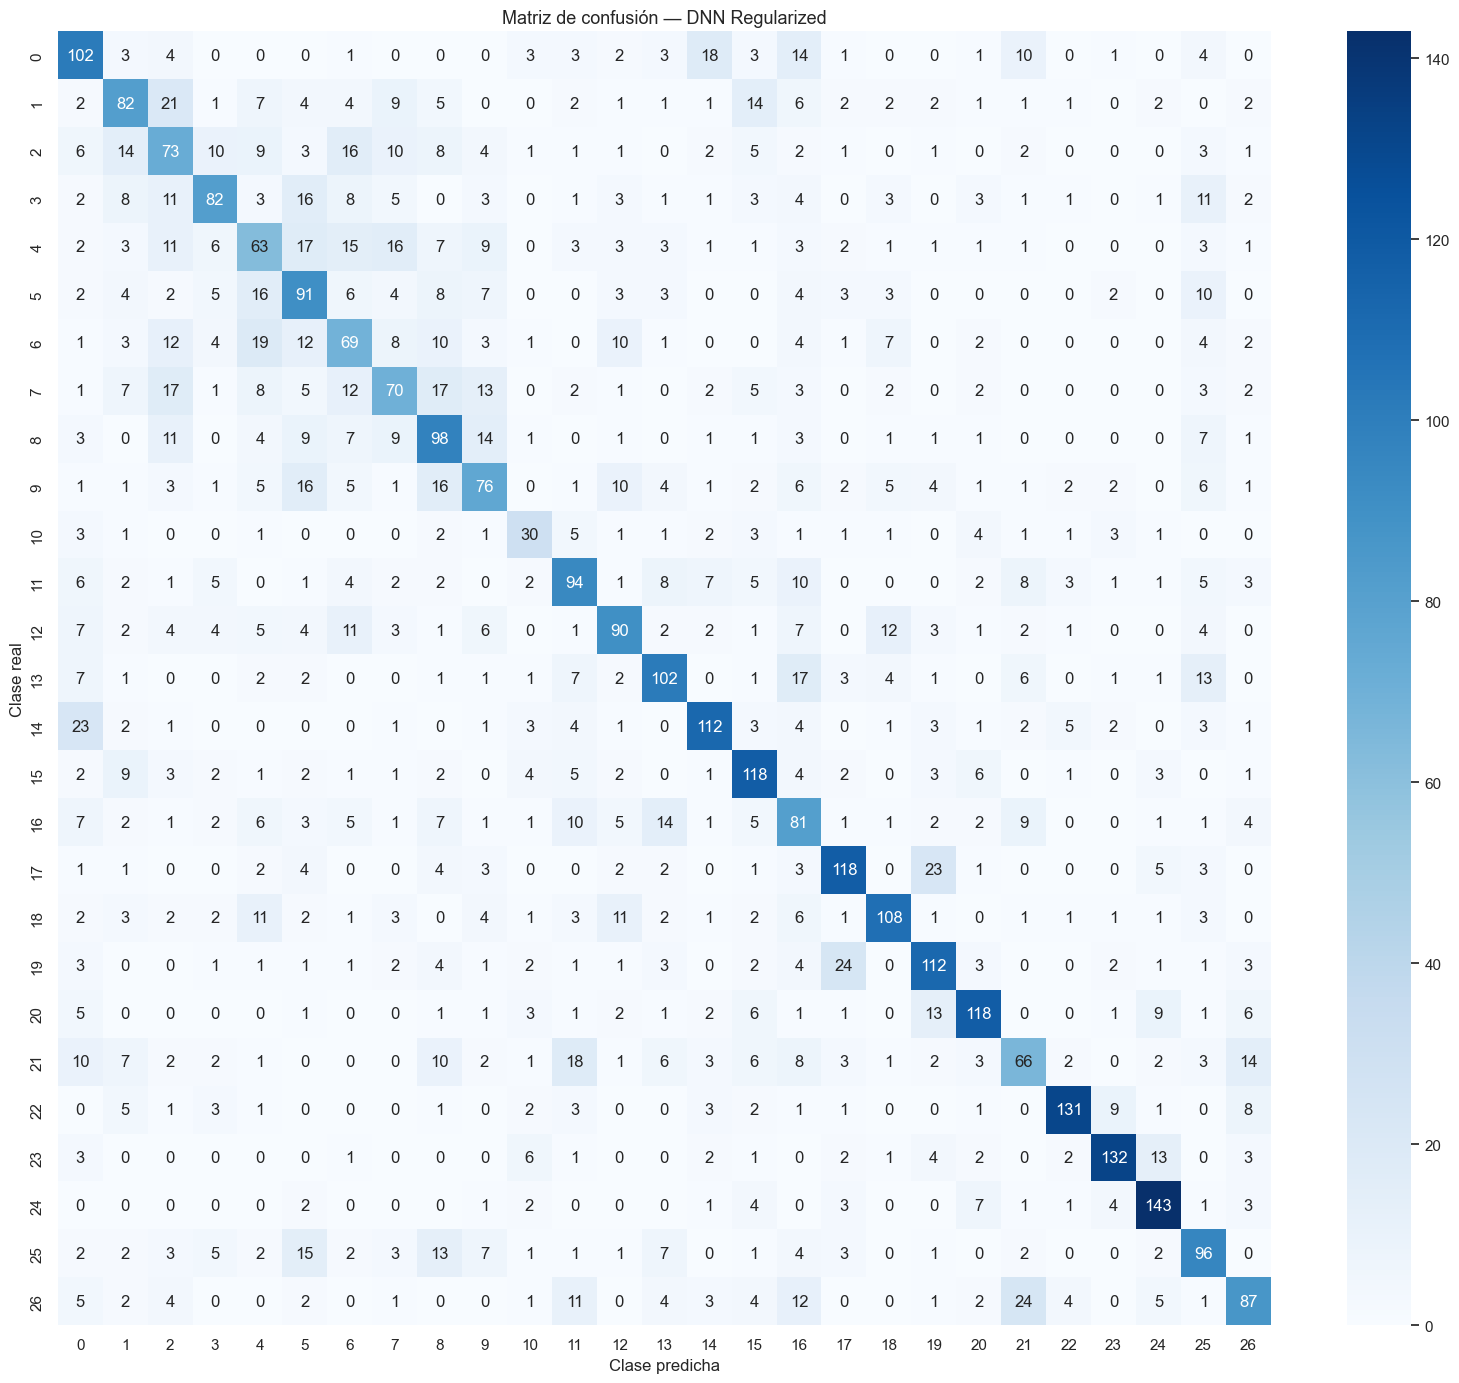


Mejor modelo: DNN Regularized
              precision    recall  f1-score   support

           0       0.49      0.59      0.54       173
           1       0.50      0.47      0.49       173
           2       0.39      0.42      0.41       173
           3       0.60      0.47      0.53       173
           4       0.38      0.36      0.37       173
           5       0.43      0.53      0.47       173
           6       0.41      0.40      0.40       173
           7       0.47      0.40      0.43       173
           8       0.45      0.57      0.50       173
           9       0.48      0.44      0.46       173
          10       0.45      0.48      0.47        63
          11       0.53      0.54      0.54       173
          12       0.58      0.52      0.55       173
          13       0.61      0.59      0.60       173
          14       0.67      0.65      0.66       173
          15       0.59      0.68      0.63       173
          16       0.38      0.47      0.42       

In [13]:
# Usar el modelo con mayor F1 macro
best_name = df_sl['F1 Macro'].idxmax()
best_model = trained_models[best_name]

y_pred_best = np.argmax(best_model.predict(X_test, verbose=0), axis=1)
cm = confusion_matrix(y_test_int, y_pred_best)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(NUM_CLASSES),
            yticklabels=range(NUM_CLASSES))
plt.title(f'Matriz de confusión — {best_name}', fontsize=13)
plt.xlabel('Clase predicha')
plt.ylabel('Clase real')
plt.tight_layout()
plt.show()

print(f'\nMejor modelo: {best_name}')
print(classification_report(y_test_int, y_pred_best))

## 10. Análisis por clase — F1-score

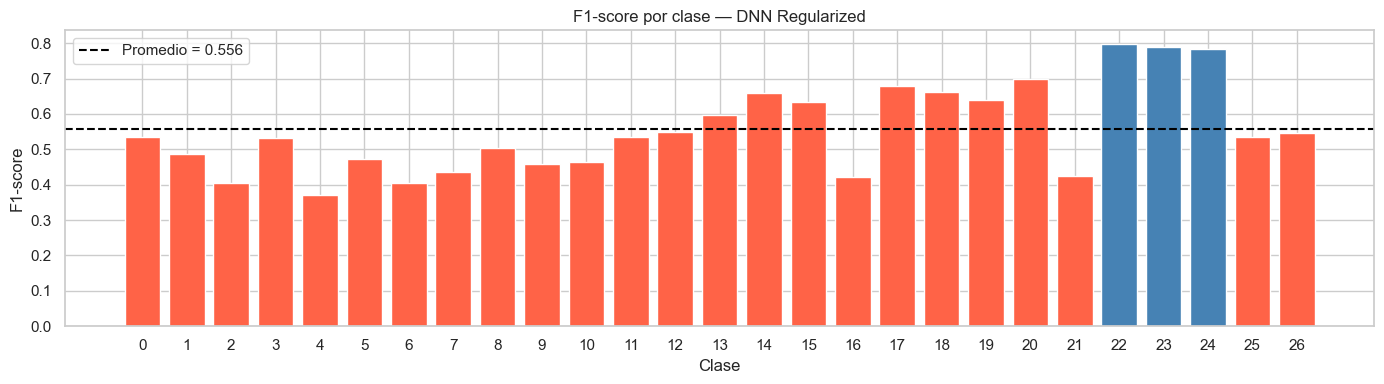

Clases con peor F1:  [4, 6, 2, 16, 21] → [0.371, 0.404, 0.406, 0.421, 0.424]
Clases con mejor F1: [17, 20, 24, 23, 22] → [0.678, 0.698, 0.784, 0.79, 0.796]


In [14]:
f1_per_class = f1_score(y_test_int, y_pred_best, average=None)

plt.figure(figsize=(14, 4))
colors = ['tomato' if f < 0.7 else 'steelblue' for f in f1_per_class]
plt.bar(range(NUM_CLASSES), f1_per_class, color=colors)
plt.axhline(y=np.mean(f1_per_class), color='black', linestyle='--', label=f'Promedio = {np.mean(f1_per_class):.3f}')
plt.title(f'F1-score por clase — {best_name}')
plt.xlabel('Clase')
plt.ylabel('F1-score')
plt.legend()
plt.xticks(range(NUM_CLASSES))
plt.tight_layout()
plt.show()

worst = np.argsort(f1_per_class)[:5]
best_classes = np.argsort(f1_per_class)[-5:]
print(f'Clases con peor F1:  {worst.tolist()} → {f1_per_class[worst].round(3).tolist()}')
print(f'Clases con mejor F1: {best_classes.tolist()} → {f1_per_class[best_classes].round(3).tolist()}')